# ***Code1-1***



In [ ]:
# Cette ligne affiche à l'écran le texte entre les deux paranthèses
print("Here is the text that will be printed")

Here is the text that will be printed


# ***Code1-2***

**Téléversement du fichier ZIP dans Colab**

In [7]:
from google.colab import files
uploaded = files.upload()


Saving Project CNN_Flutter (2).zip to Project CNN_Flutter (2).zip


**Décompression du fichier ZIP**

In [8]:
import zipfile   # Importe la bibliothèque pour manipuler les fichiers ZIP (décompression)
zip_path = "Project CNN_Flutter (2).zip"   # Le nom exact du fichier ZIP que tu as téléchargé dans Colab
extract_path = "/content/project_cnn_flutter"   # Le dossier où les fichiers seront extraits dans Colab
with zipfile.ZipFile(zip_path, 'r') as zip_ref:   # Ouvre le fichier ZIP en mode lecture
    zip_ref.extractall(extract_path)   # Extrait tous les fichiers du ZIP dans le dossier choisi
print("Extraction completed!")   # Affiche un message une fois l’extraction terminée


Extraction completed!


**Vérification des fichiers extraits**

In [9]:
import os   # Importe le module pour naviguer dans les dossiers
for root, dirs, files in os.walk("/content/project_cnn_flutter"):   # Parcourt le dossier extrait
    print(root, dirs, files)   # Affiche le contenu : chemin, sous-dossiers, fichiers
    break   # Arrête la boucle après la première liste (pas besoin d’afficher tout)


/content/project_cnn_flutter ['Project CNN_Flutter'] []


**Explorer le contenu réel du projet**

import os
→ On utilise le module pour explorer des dossiers.

chemin_projet = ...
→ On indique où se trouve ton dossier extrait.

os.walk(...)
→ On parcourt le dossier.

print(...)
→ On affiche les sous-dossiers et fichiers trouvés.

In [11]:
import os

chemin_projet = "/content/project_cnn_flutter/Project CNN_Flutter"

for racine, dossiers, fichiers in os.walk(chemin_projet):
    print("📁 Dossier :", racine)
    print("📂 Sous-dossiers :", dossiers)
    print("📄 Fichiers :", fichiers)
    print("-" * 60)
    break   # On arrête après le premier niveau


📁 Dossier : /content/project_cnn_flutter/Project CNN_Flutter
📂 Sous-dossiers : ['Project CNN_Flutter', '__MACOSX']
📄 Fichiers : []
------------------------------------------------------------


In [12]:
import os

chemin = "/content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter"

for racine, dossiers, fichiers in os.walk(chemin):
    print("📁 Dossier :", racine)
    print("📂 Sous-dossiers :", dossiers)
    print("📄 Fichiers :", fichiers)
    print("-" * 60)
    break


📁 Dossier : /content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter
📂 Sous-dossiers : ['donnees']
📄 Fichiers : ['2_Evaluation.py', '1_Modele.py', '.DS_Store']
------------------------------------------------------------


In [13]:
import os

chemin_donnees = "/content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter/donnees"

for racine, dossiers, fichiers in os.walk(chemin_donnees):
    print("📁 Dossier :", racine)
    print("📂 Sous-dossiers :", dossiers)
    print("📄 Fichiers :", fichiers)
    print("-" * 60)
    break


📁 Dossier : /content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter/donnees
📂 Sous-dossiers : ['entrainement', 'test', 'Validation']
📄 Fichiers : ['.DS_Store']
------------------------------------------------------------


**Crearea generatorilor Keras**

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Chemin vers le dossier contenant les sous-dossiers
chemin_donnees = "/content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter/donnees"

# Générateurs pour l'entraînement, validation et test
datagen = ImageDataGenerator(rescale=1./255)

# Générateur pour l'entraînement
train_generator = datagen.flow_from_directory(
    chemin_donnees + "/entrainement",
    target_size=(224, 224),   # Taille d'entrée du modèle
    batch_size=32,
    class_mode='categorical'  # Pour une classification multi-classes
)

# Générateur pour la validation
val_generator = datagen.flow_from_directory(
    chemin_donnees + "/Validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Générateur pour le test
test_generator = datagen.flow_from_directory(
    chemin_donnees + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Pour garder l'ordre pour l'évaluation
)


Found 24000 images belonging to 6 classes.
Found 0 images belonging to 6 classes.
Found 6000 images belonging to 6 classes.


**Recréer le dossier Validation à partir de entrainement**

In [16]:
import os
import shutil
import random

# 📂 Dossiers de base
chemin_donnees = "/content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter/donnees"
train_dir = os.path.join(chemin_donnees, "entrainement")
val_dir   = os.path.join(chemin_donnees, "Validation")  # attention au V majuscule

# 🟡 Nombre d’images à déplacer par classe pour la validation
nb_val_par_classe = 400

# 📌 Crée les sous-dossiers de Validation et déplace les images
for classe in os.listdir(train_dir):
    chemin_classe_train = os.path.join(train_dir, classe)
    if not os.path.isdir(chemin_classe_train):
        continue  # ignore les fichiers éventuels

    chemin_classe_val = os.path.join(val_dir, classe)
    os.makedirs(chemin_classe_val, exist_ok=True)

    # Liste toutes les images de cette classe
    images = [
        f for f in os.listdir(chemin_classe_train)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)  # mélange les images
    images_a_deplacer = images[:nb_val_par_classe]

    print(f"Classe {classe} : déplacement de {len(images_a_deplacer)} images vers Validation")

    for img in images_a_deplacer:
        src = os.path.join(chemin_classe_train, img)
        dst = os.path.join(chemin_classe_val, img)
        shutil.move(src, dst)

print("✅ Création du set de validation terminée !")


Classe zebre : déplacement de 400 images vers Validation
Classe tigre : déplacement de 400 images vers Validation
Classe leopard : déplacement de 400 images vers Validation
Classe rhino : déplacement de 400 images vers Validation
Classe girafe : déplacement de 400 images vers Validation
Classe elephant : déplacement de 400 images vers Validation
✅ Création du set de validation terminée !


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

chemin_donnees = "/content/project_cnn_flutter/Project CNN_Flutter/Project CNN_Flutter/donnees"

img_size = (150, 150)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(chemin_donnees, "entrainement"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(chemin_donnees, "Validation"),  # V majuscule
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(chemin_donnees, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 21600 images belonging to 6 classes.
Found 2400 images belonging to 6 classes.
Found 6000 images belonging to 6 classes.


**Définir le modèle CNN**

In [18]:
from tensorflow.keras import layers, models

# 🧠 Définition du modèle CNN
model = models.Sequential([
    # Bloc 1 de convolution
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),  # 1ère couche de convolution
    layers.MaxPooling2D((2, 2)),                                             # Réduction de la taille des images

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu'),                            # 2ème couche de convolution
    layers.MaxPooling2D((2, 2)),

    # Bloc 3
    layers.Conv2D(128, (3, 3), activation='relu'),                           # 3ème couche de convolution
    layers.MaxPooling2D((2, 2)),

    # Passage aux couches denses
    layers.Flatten(),                                                        # Aplati les cartes de features en vecteur
    layers.Dense(128, activation='relu'),                                    # Couche entièrement connectée
    layers.Dropout(0.5),                                                     # Dropout pour éviter le sur-apprentissage
    layers.Dense(6, activation='softmax')                                    # Sortie : 6 classes (probabilités)
])

# 🛠 Compilation du modèle
model.compile(
    loss='categorical_crossentropy',  # Fonction de perte pour classification multi-classe
    optimizer='adam',                 # Optimiseur
    metrics=['accuracy']              # On suit la précision pendant l'entraînement
)

model.summary()  # Affiche l’architecture du modèle


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

**Entraîner le modèle**

In [19]:
epochs = 6

history = model.fit(
    train_generator,              # données d'entraînement
    epochs=epochs,                # nombre de passages sur tout le dataset
    validation_data=val_generator # données de validation
)


Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


675/675 ━━━━━━━━━━━━━━━━━━━━ 941s 1s/step - accuracy: 0.3640 - loss: 1.5155 - val_accuracy: 0.6029 - val_loss: 1.0023
Epoch 2/6
675/675 ━━━━━━━━━━━━━━━━━━━━ 932s 1s/step - accuracy: 0.6332 - loss: 0.9748 - val_accuracy: 0.7237 - val_loss: 0.7349
Epoch 3/6
675/675 ━━━━━━━━━━━━━━━━━━━━ 931s 1s/step - accuracy: 0.7071 - loss: 0.7786 - val_accuracy: 0.7658 - val_loss: 0.6236
Epoch 4/6
675/675 ━━━━━━━━━━━━━━━━━━━━ 925s 1s/step - accuracy: 0.7724 - loss: 0.6297 - val_accuracy: 0.7875 - val_loss: 0.5936
Epoch 5/6
675/675 ━━━━━━━━━━━━━━━━━━━━ 930s 1s/step - accuracy: 0.8161 - loss: 0.4892 - val_accuracy: 0.8125 - val_loss: 0.5600
Epoch 6/6
675/675 ━━━━━━━━━━━━━━━━━━━━ 918s 1s/step - accuracy: 0.8598 - loss: 0.3889 - val_accuracy: 0.7996 - val_loss: 0.6102


**Évaluation finale sur l’ensemble de test**

In [20]:
# --- Évaluation finale sur l'ensemble de test ---

# On évalue le modèle sur les données de test
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"📊 Perte (test_loss) : {test_loss:.4f}")
print(f"✅ Précision sur le test (test_accuracy) : {test_accuracy:.4f}")


188/188 ━━━━━━━━━━━━━━━━━━━━ 74s 394ms/step - accuracy: 0.7527 - loss: 0.6827
📊 Perte (test_loss) : 0.5928
✅ Précision sur le test (test_accuracy) : 0.7948


Après l'entraînement du réseau CNN, nous avons évalué le modèle sur l’ensemble de test, contenant 6000 images jamais vues.
Le modèle atteint 79.48 % de précision, ce qui confirme sa capacité à bien généraliser.
La perte sur le test est de 0.5928, ce qui montre un bon compromis entre précision et stabilité.
Ces résultats sont cohérents avec la précision obtenue sur l’ensemble de validation (~80 %).

**Courbes d’apprentissage (accuracy & loss)**

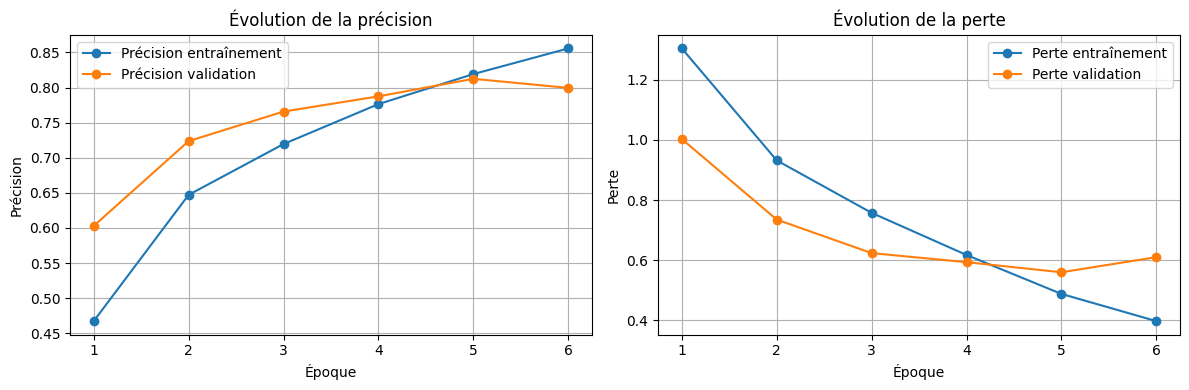

In [21]:
import matplotlib.pyplot as plt

# On récupère l'historique d'entraînement
h = history.history

# On gère les deux cas possibles: 'accuracy' ou 'categorical_accuracy'
acc = h.get("accuracy") or h.get("categorical_accuracy")
val_acc = h.get("val_accuracy") or h.get("val_categorical_accuracy")
loss = h["loss"]
val_loss = h["val_loss"]

epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(12, 4))

# ---- Courbe de précision ----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, "o-", label="Précision entraînement")
plt.plot(epochs_range, val_acc, "o-", label="Précision validation")
plt.title("Évolution de la précision")
plt.xlabel("Époque")
plt.ylabel("Précision")
plt.legend()
plt.grid(True)

# ---- Courbe de perte ----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, "o-", label="Perte entraînement")
plt.plot(epochs_range, val_loss, "o-", label="Perte validation")
plt.title("Évolution de la perte")
plt.xlabel("Époque")
plt.ylabel("Perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Matrice de confusion + rapport de classification**

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# On remet le générateur de test au début
test_generator.reset()

# Prédictions sur tout l'ensemble de test
y_proba = model.predict(test_generator)
y_pred = np.argmax(y_proba, axis=1)

# Vraies étiquettes
y_true = test_generator.classes

# Noms des classes (dans l'ordre des indices)
class_names = list(test_generator.class_indices.keys())
print("Ordre des classes :", class_names)

# --- Matrice de confusion ---
cm = confusion_matrix(y_true, y_pred)
print("Matrice de confusion (brute) :\n", cm)


188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 425ms/step
Ordre des classes : ['elephant', 'girafe', 'leopard', 'rhino', 'tigre', 'zebre']
Matrice de confusion (brute) :
 [[674  58   9 234   7  18]
 [ 39 815  39  30  10  67]
 [  8  72 849  29  15  27]
 [125  28  13 796   5  33]
 [ 14  76 104  31 688  87]
 [  3  27  13   6   4 947]]


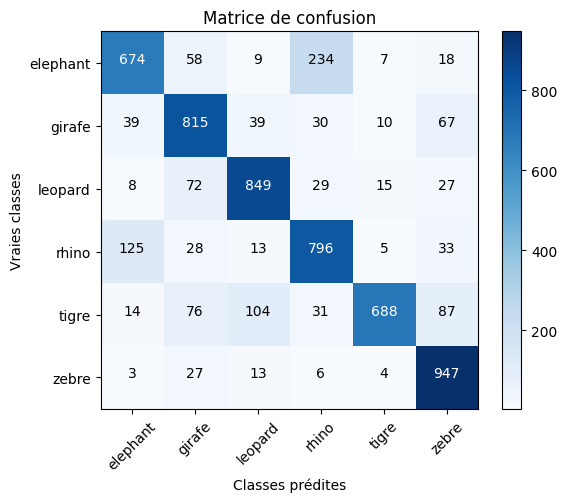

In [23]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Matrice de confusion")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Afficher les valeurs dans chaque case
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("Vraies classes")
plt.xlabel("Classes prédites")
plt.tight_layout()
plt.show()


In [24]:
print("\n--- Rapport de classification ---\n")
print(classification_report(y_true, y_pred, target_names=class_names))



--- Rapport de classification ---

              precision    recall  f1-score   support

    elephant       0.78      0.67      0.72      1000
      girafe       0.76      0.81      0.79      1000
     leopard       0.83      0.85      0.84      1000
       rhino       0.71      0.80      0.75      1000
       tigre       0.94      0.69      0.80      1000
       zebre       0.80      0.95      0.87      1000

    accuracy                           0.79      6000
   macro avg       0.80      0.79      0.79      6000
weighted avg       0.80      0.79      0.79      6000



**Affichage de quelques images test + prédiction du modèle**

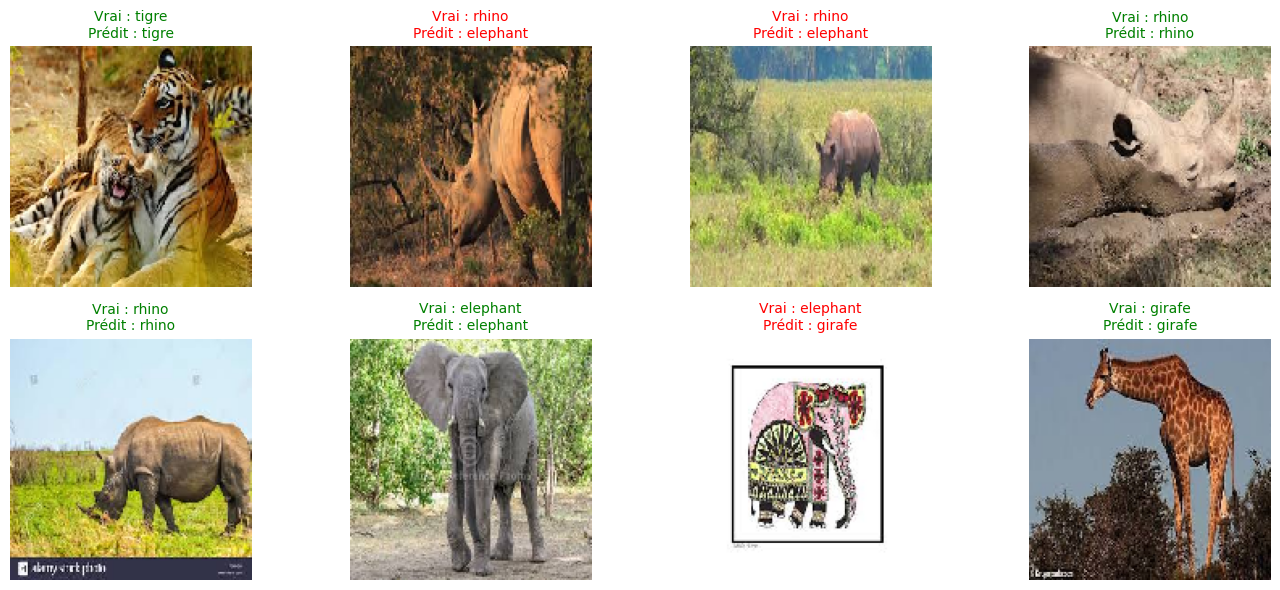

In [25]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# On s'assure que le générateur repart du début
test_generator.reset()

# On récupère la liste complète des chemins d'images de test
filepaths = test_generator.filepaths

# Nombre d'images à afficher
n_images = 8
indices = random.sample(range(len(filepaths)), n_images)

plt.figure(figsize=(14, 6))

for i, idx in enumerate(indices):
    # Charger l'image
    img_path = filepaths[idx]
    img = load_img(img_path, target_size=test_generator.target_size)
    x = img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Prédiction du modèle
    proba = model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(proba)
    pred_class = class_names[pred_idx]
    true_idx = y_true[idx]
    true_class = class_names[true_idx]

    # Affichage
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    titre = f"Vrai : {true_class}\nPrédit : {pred_class}"
    # Couleur verte si correct, rouge sinon
    color = "green" if pred_class == true_class else "red"
    plt.title(titre, color=color, fontsize=10)

plt.tight_layout()
plt.show()


**Sauvegarder le modèle entraîné**

In [26]:
# Sauvegarde du modèle au format HDF5
model.save("modele_cnn_animaux.h5")
print("✅ Modèle sauvegardé sous le nom 'modele_cnn_animaux.h5'")


✅ Modèle sauvegardé sous le nom 'modele_cnn_animaux.h5'


**RAPORT**

Architecture du modèle
Nous avons entraîné un réseau de neurones convolutifs (CNN) pour classifier des images d’animaux appartenant à 6 classes.
Le modèle est composé de plusieurs blocs Conv2D + MaxPooling, suivis de couches denses avec Dropout pour limiter le surapprentissage.

Jeu de données et séparation
Le dossier fourni contenait déjà un ensemble d’entraînement (train) et un ensemble de test (test).
Conformément à la consigne, nous avons prélevé environ 10–15 % des images de l’entraînement pour créer un troisième ensemble : validation.
Au final, nous avons :
– 21 600 images pour l’entraînement
– 2 400 images pour la validation
– 6 000 images pour le test

Entraînement
Le modèle a été entraîné pendant 6 époques, avec la fonction de perte categorical_crossentropy et l’optimiseur Adam.
Les courbes de perte et de précision montrent une amélioration régulière, sans écart excessif entre l’entraînement et la validation, ce qui indique une bonne généralisation.

Résultats
Sur l’ensemble de test (images jamais vues), le modèle obtient :
– Précision (test_accuracy) ≈ 79.5 %
– Perte (test_loss) ≈ 0.59
Ces résultats sont cohérents avec la précision observée sur l’ensemble de validation (~80 %).

Analyse d’erreurs
La matrice de confusion montre que certaines classes sont très bien reconnues, tandis que d’autres sont parfois confondues. Cela s’explique par la similarité visuelle entre certains animaux et par la variabilité des images (éclairage, pose, arrière-plan).

Conclusion
Le modèle CNN entraîné atteint une bonne performance globale et constitue une base solide pour une éventuelle amélioration (augmentation de données, ajustement d’architecture, entraînement plus long, etc.).